# **Apartment Hunter**

In [48]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 1. **EDA (Cleaning and traitment)**

### Get dataset, missing values, duplicates, general infos

In [49]:
df = pd.read_csv("data/raw/kc_house_data.csv", sep=",")

print(f"\nDimensions of the raw dataset : {df.shape}")

# Verification of missing values
print("\nMissing values per columns :")
print(df.isnull().sum())
# Traitment of missing values = No need to do


# Deleting duplicates
n_before = len(df)
df = df.drop_duplicates()
print(f"\nDropped duplicates : {n_before - len(df)}")

print("\nTypes of columns :")
print(df.info())

print("\nPreview of the opening lines :")
print(df.head())


Dimensions of the raw dataset : (21613, 21)

Missing values per columns :
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Dropped duplicates : 0

Types of columns :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqf

### Standardization columns (names and types)

In [50]:
renovation_outlier = df[(df['yr_renovated'] != 0) & (df['yr_renovated'] < df['yr_built'])]
rooms_outlier = df[(df["bathrooms"] > df["bedrooms"] + 2)]

print(len(renovation_outlier),len(rooms_outlier))
rooms_outlier.head()
df.drop(index=rooms_outlier.index)


df = df.drop('date', axis=1)
df = df.drop('id',axis=1)

0 3


In [51]:
df["price_per_living_sqft"]=df["price"]/df['sqft_living']
df["price_per_lot_sqft"]=df["price"]/df['sqft_lot']
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_per_living_sqft,price_per_lot_sqft
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,...,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,264.156594,88.966710
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,110.060793,94.055247
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,87.588235,0.163119
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,182.291667,33.333333
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,244.644550,59.223301
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,318.322981,107.594937
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,810.138889,2027.208539


In [ ]:
df['sqm_living']=df['sqft_living']* 0.092903
df['sqm_lot']=df['sqft_lot']* 0.092903
df['sqm_basement']=df['sqft_basement']* 0.092903
df['sqm_living15']=df['sqft_living15']* 0.092903
df['sqm_price_per_lot']=df['price_per_lot_sqft']* 0.092903
df['sqm_price_per_living']=df['price_per_living_sqft']* 0.092903
df['sqm_lot15']=df['sqft_lot15']* 0.092903
df['sqm_above']=df['sqft_above']* 0.092903
df = df.drop(columns=["sqft_above", 'sqft_living', 'sqft_lot', 'sqft_basement', 'sqft_living15', 'price_per_lot_sqft', 'price_per_living_sqft', 'sqft_lot15'])

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,yr_built,yr_renovated,...,lat,long,sqm_living,sqm_lot,sqm_basement,sqm_living15,sqm_price_per_lot,sqm_price_per_living,sqm_lot15,sqm_above
0,221900.0,3,1.00,1.0,0,0,3,7,1955,0,...,47.5112,-122.257,109.62554,524.901950,0.00000,124.49002,3.648704,17.470488,524.901950,109.62554
1,538000.0,3,2.25,2.0,0,0,3,7,1951,1991,...,47.7210,-122.319,238.76071,672.803526,37.16120,157.00607,6.901659,19.448177,709.686017,201.59951
2,180000.0,2,1.00,1.0,0,0,3,6,1933,0,...,47.7379,-122.233,71.53531,929.030000,0.00000,252.69616,1.672254,21.717584,748.983986,71.53531
3,604000.0,4,3.00,1.0,0,0,5,7,1965,0,...,47.5208,-122.393,182.08988,464.515000,84.54173,126.34808,11.222682,28.629292,464.515000,97.54815
4,510000.0,3,2.00,1.0,0,0,3,8,1987,0,...,47.6168,-122.045,156.07704,750.656240,0.00000,167.22540,5.863927,28.202696,697.051209,156.07704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,3.0,0,0,3,8,2009,0,...,47.6993,-122.346,142.14159,105.073293,0.00000,142.14159,29.571247,21.859529,140.190627,142.14159
21609,400000.0,4,2.50,2.0,0,0,3,8,2014,0,...,47.5107,-122.362,214.60593,540.045139,0.00000,170.01249,6.392775,16.087100,668.901600,214.60593
21610,402101.0,2,0.75,2.0,0,0,3,7,2009,0,...,47.5944,-122.299,94.76106,125.419050,0.00000,94.76106,27.671399,36.623911,186.456321,94.76106
21611,400000.0,3,2.50,2.0,0,0,3,8,2004,0,...,47.5345,-122.069,148.64480,221.852364,0.00000,130.99323,15.561642,23.225750,119.566161,148.64480


### Data distribution for visualizing potential outliers

In [58]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,price_per_living_sqft,price_per_lot_sqft,sqm_living,sqm_lot,sqm_basement,sqm_living15,sqm_price_per_lot,sqm_price_per_living,sqm_lot15,sqm_above
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,...,264.156594,88.966710,193.228925,1403.482608,27.082065,184.556686,8.265274,24.540940,1186.227835,166.146860
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,110.060793,94.055247,85.325915,3848.089781,41.116549,63.674908,8.738015,10.224978,2536.640200,76.932136
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,87.588235,0.163119,26.941870,48.309560,0.000000,37.068297,0.015154,8.137210,60.479853,26.941870
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,182.291667,33.333333,132.572581,468.231120,0.000000,138.425470,3.096767,16.935443,473.805300,110.554570
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,244.644550,59.223301,177.444730,707.735054,0.000000,170.941520,5.502022,22.728213,707.920860,144.928680
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,318.322981,107.594937,236.902650,992.947264,52.025680,219.251080,9.995892,29.573160,936.740949,205.315630
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,810.138889,2027.208539,1257.906620,153416.205177,447.792460,576.927630,188.333755,75.264333,80937.093600,874.217230


Thanks to the `describe` method, no outliers are detected.

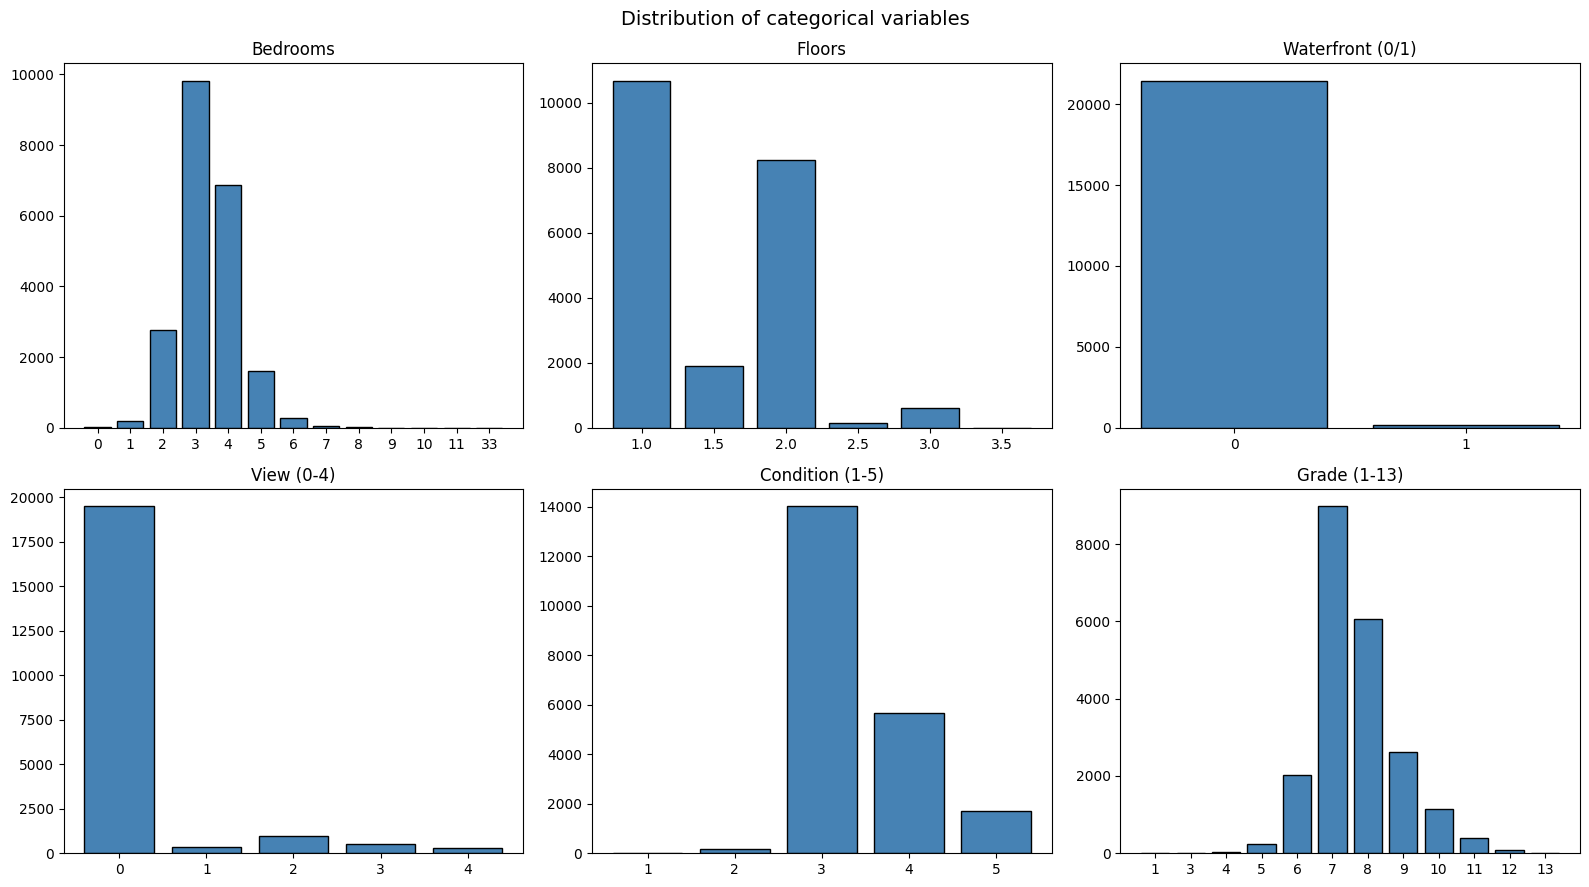

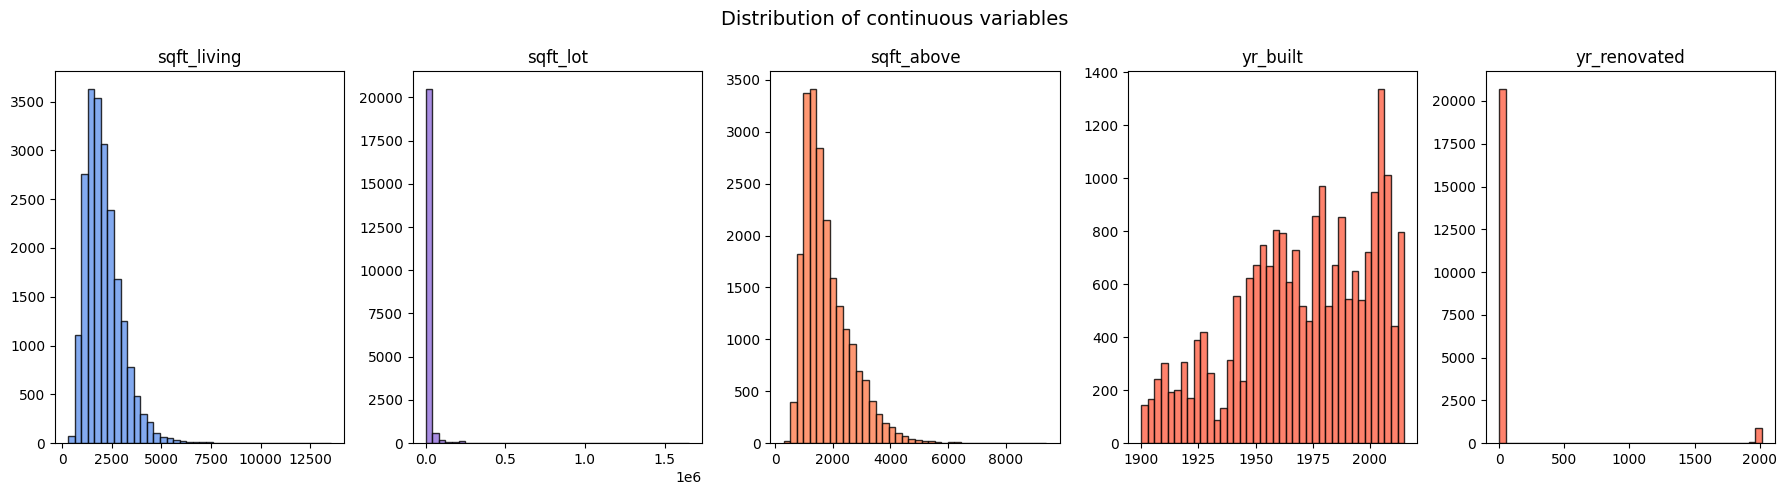

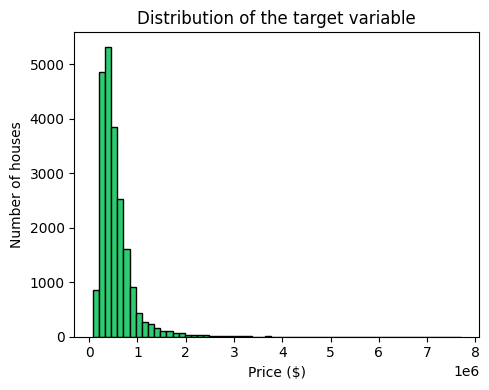

Price statistics : {'count': 21613.0, 'mean': 540088.0, 'std': 367127.0, 'min': 75000.0, '25%': 321950.0, '50%': 450000.0, '75%': 645000.0, 'max': 7700000.0}


In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of categorical variables", fontsize=14)

categoricals = ['bedrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']
titles = ['Bedrooms', 'Floors', 'Waterfront (0/1)', 'View (0-4)', 'Condition (1-5)', 'Grade (1-13)']

for ax, col, title in zip(axes.flatten(), categoricals, titles):
    counts = df[col].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(i) for i in counts.index], rotation=0)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Distribution of continuous variables", fontsize=14)
for ax, col, color in zip(axes,
                           ['sqm_living', 'sqm_lot', 'sqm_above', 'yr_built', 'yr_renovated'],
                           ['cornflowerblue', 'mediumpurple', 'coral', 'tomato', 'tomato']):
    ax.hist(df[col], bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(col)
plt.tight_layout()
plt.show()



plt.figure(figsize=(5, 4))
plt.hist(df['price'], bins=60, color='#2ecc71', edgecolor='black')
plt.title("Distribution of the target variable")
plt.xlabel("Price ($)")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()
print(f"Price statistics : {df['price'].describe().round(0).to_dict()}")

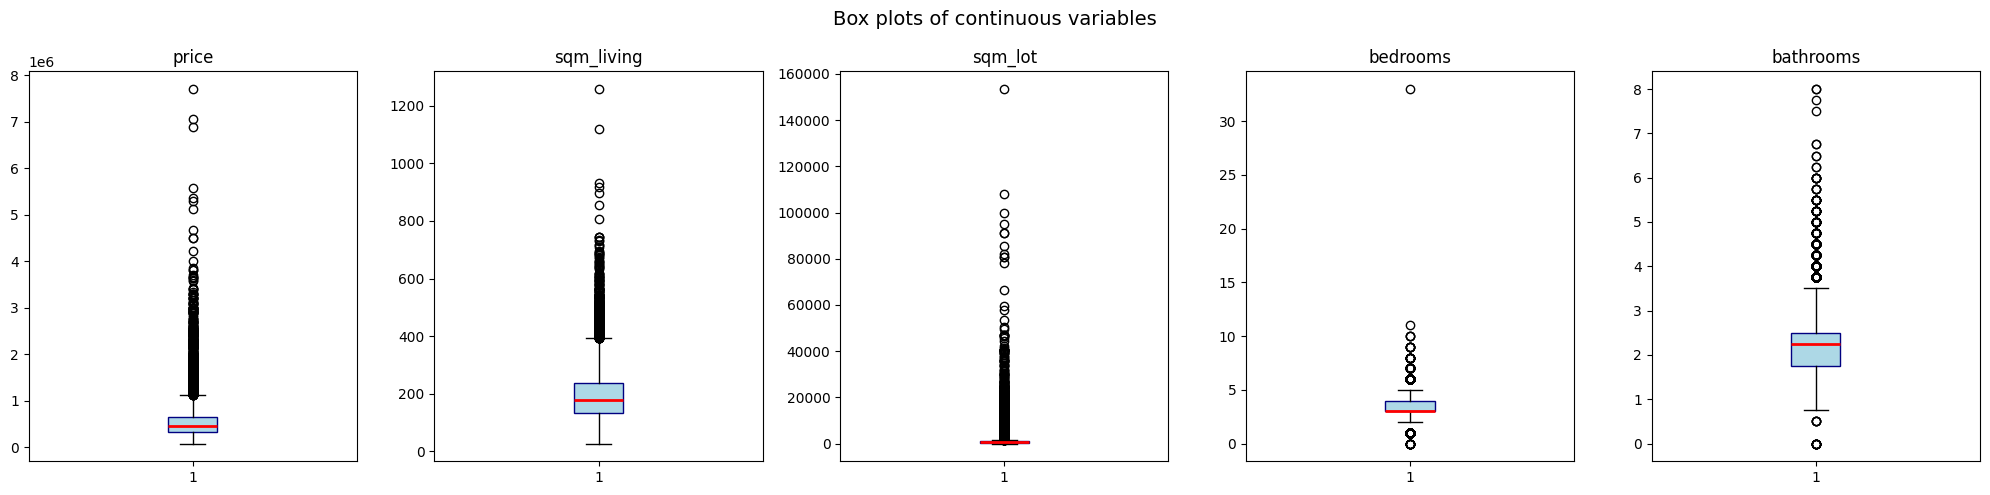

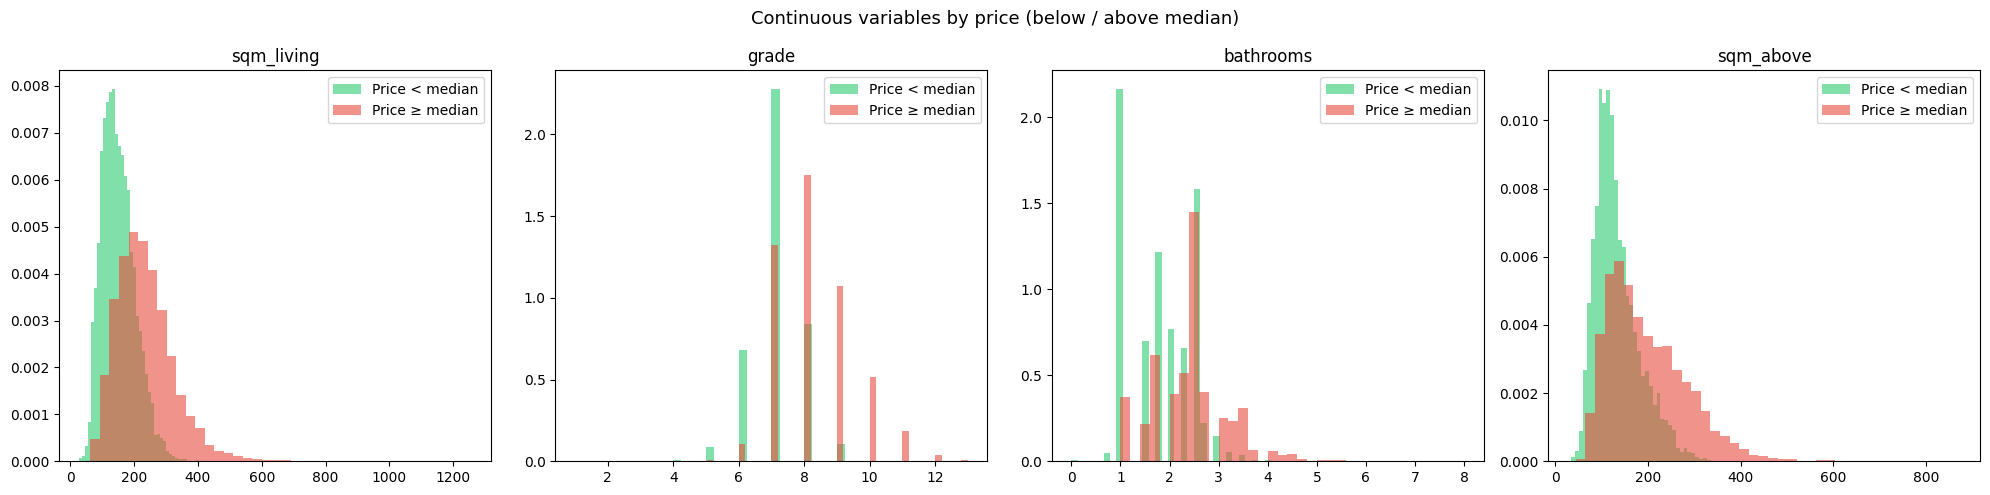

In [55]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Box plots of continuous variables", fontsize=14)
for ax, col in zip(axes, ['price', 'sqm_living', 'sqm_lot', 'bedrooms', 'bathrooms']):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Continuous variables by price (below / above median)",
             fontsize=13)
for ax, col in zip(axes, ['sqm_living', 'grade', 'bathrooms', 'sqm_above']):
    for val, label, color in [(False, 'Price < median', '#2ecc71'), (True, 'Price ≥ median', '#e74c3c')]:
        ax.hist(df[(df['price'] >= df['price'].median()) == val][col], bins=40,
                alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

### Saving in clean folder

In [56]:
os.makedirs("data/clean", exist_ok=True)

df.to_csv("data/clean/kc_house_data_clean.csv", index=False)

print("\nSaved in clean folder.")


Saved in clean folder.
